# NBA Player Clustering with Unsupervised Learning

### Dataset
This project combines two datasets from Basketball Reference for the 2025-26 NBA season:

- NBA Advanced Player Stats: https://www.basketball-reference.com/leagues/NBA_2026_advanced.html
- NBA Shooting Stats: https://www.basketball-reference.com/leagues/NBA_2026_shooting.html

The shooting table adds shot location data including distance, zone percentages, 
corner three rate, dunk frequency, and assisted shot rates. Combined with advanced 
stats, this gives a richer picture of how each player actually plays rather than 
just how much they produce.

## Goal

Group NBA players into four archetypes based on their combined advanced and 
shooting stats:

- **Floor Spacers** — perimeter players whose shot profile and distance 
  separate them from interior players.
- **Star Playmakers** — high-impact players who drive team offense through 
  scoring, playmaking, and overall efficiency.
- **Rim Runners** — athletic bigs who dominate at the rim through dunking, 
  offensive rebounding, and paint finishing.
- **Interior Enforcers** — pure paint bigs with near-zero perimeter activity 
  and extreme inside finishing.

## Why Clustering?

Instead of labeling players manually, we let the data decide the natural groupings. 
Unsupervised learning (Agglomerative Clustering + PCA) helps us:

- Reduce redundancy in correlated stats via PCA.
- Separate players into clusters that highlight their true role and impact.

## Purpose

This analysis shows how data can separate stars from role players and reveal 
meaningful distinctions within traditional positions. By combining advanced 
efficiency metrics with shot location data, we can identify not just who is 
productive but how and where they produce. Coaches, analysts, and front offices 
can use these archetypes to evaluate fit, identify replacements, and understand 
which players drive winning.

## Advanced NBA Stats Glossary

**Basic**
- Pos — Position
- G — Games
- GS — Games Started
- MP — Minutes Played

**Advanced**
- PER — Player Efficiency Rating. Per-minute production standardized to league average of 15.
- TS% — True Shooting Percentage. Shooting efficiency using 2P, 3P, and FT.
- 3PAr — 3-Point Attempt Rate. Percentage of FG attempts from three point range.
- FTr — Free Throw Attempt Rate. FT attempts per FG attempt.
- ORB% — Offensive Rebound Percentage.
- DRB% — Defensive Rebound Percentage.
- TRB% — Total Rebound Percentage. Estimated percentage of available rebounds grabbed.
- AST% — Assist Percentage. Estimated percentage of teammate FGs assisted.
- STL% — Steal Percentage.
- BLK% — Block Percentage. Estimated percentage of opponent FG attempts blocked.
- TOV% — Turnover Percentage. Turnovers per 100 plays.
- USG% — Usage Percentage. Percentage of team plays used while on the floor.
- OWS — Offensive Win Shares.
- DWS — Defensive Win Shares.
- WS — Win Shares.
- WS/48 — Win Shares per 48 minutes. League average is approximately 0.100.
- OBPM — Offensive Box Plus/Minus.
- DBPM — Defensive Box Plus/Minus.
- BPM — Box Plus/Minus. Estimated points per 100 possessions above a league-average player.
- VORP — Value Over Replacement Player. Estimated points per 100 team possessions 
  above replacement level, prorated to an 82-game season.

**Shooting (from shooting table)**
- FG% — Field Goal Percentage.
- Dist. — Average shot distance in feet.
- pct_fga_0-3 — Percentage of FGA from 0 to 3 feet.
- pct_fga_3P — Percentage of FGA from three point range.
- fg_pct_3P — Field goal percentage on three point attempts.
- corner3_%3PA — Percentage of three point attempts from the corner.
- corner3_3P% — Three point percentage on corner attempts.
- dunks_%FGA — Percentage of FGA that are dunks.
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
!conda install -y lxml


# Load dataset
url = "https://www.basketball-reference.com/leagues/NBA_2026_advanced.html"  # your link
tables = pd.read_html(url)   # grabs all tables on the page
df = tables[0]               # usually the first table



Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [2]:
# Load totals dataset
url2 = "https://www.basketball-reference.com/leagues/NBA_2026_shooting.html"
tables = pd.read_html(url2)
df_shooting = tables[0]



In [3]:
def get_group_name(top_header):
    top_header = str(top_header)

    if top_header.startswith('Unnamed'):
        return ''
    elif 'FGA by Distance' in top_header:
        return 'pct_fga'
    elif 'FG% by Distance' in top_header:
        return 'fg_pct'
    elif 'FG Ast' in top_header:
        return 'ast_pct'
    elif 'Dunks' in top_header:
        return 'dunks'
    elif 'Corner' in top_header:
        return 'corner3'
    elif 'Court' in top_header:
        return 'half_court'
    else:
        return top_header

# Turn the two-level headers into unique one-level column names
new_columns = []

for top, bottom in df_shooting.columns:
    group = get_group_name(top)
    
    if group == '':
        new_columns.append(bottom)
    else:
        new_columns.append(f'{group}_{bottom}')

df_shooting.columns = new_columns

In [4]:
shooting_stats = [
    'FG%', 'Dist.',
    'pct_fga_2P',
    'pct_fga_0-3',
    'pct_fga_3-10',
    'pct_fga_10-16',
    'pct_fga_16-3P',
    'pct_fga_3P',
    'fg_pct_2P',
    'fg_pct_0-3',
    'fg_pct_3-10',
    'fg_pct_10-16',
    'fg_pct_16-3P',
    'fg_pct_3P',
    'ast_pct_2P',
    'ast_pct_3P',
    'dunks_%FGA',
    'dunks_#',
    'corner3_%3PA',
    'corner3_3P%',
    'half_court_Att.',
    'half_court_Md.'
]

df_shooting_clean = df_shooting[['Player', 'Team'] + shooting_stats].copy()

df_shooting_clean = df_shooting_clean[
    df_shooting_clean['Player'] != 'Player'
].copy()

In [5]:


df = df.merge(
    df_shooting_clean [['Player', 'Team'] + shooting_stats],
    on=['Player', 'Team'],
    how='inner'
)

df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,fg_pct_16-3P,fg_pct_3P,ast_pct_2P,ast_pct_3P,dunks_%FGA,dunks_#,corner3_%3PA,corner3_3P%,half_court_Att.,half_court_Md.
0,1.0,Amen Thompson,23.0,HOU,PG,79.0,79.0,2953.0,18.9,0.594,...,0.333,0.216,0.530,0.960,0.209,201.0,0.586,0.235,1.0,0.0
1,2.0,Kevin Durant,37.0,HOU,SF,78.0,78.0,2840.0,21.1,0.641,...,0.512,0.413,0.472,0.731,0.042,54.0,0.102,0.500,0.0,0.0
2,3.0,Desmond Bane,27.0,ORL,SG,82.0,82.0,2756.0,16.9,0.607,...,0.397,0.391,0.526,0.796,0.002,2.0,0.197,0.440,0.0,0.0
3,4.0,Toumani Camara,25.0,POR,PF,82.0,82.0,2731.0,11.3,0.578,...,0.600,0.370,0.659,0.886,0.051,39.0,0.296,0.331,0.0,0.0
4,5.0,Jabari Smith Jr.,22.0,HOU,PF,77.0,77.0,2705.0,13.5,0.570,...,0.390,0.363,0.670,0.966,0.069,65.0,0.357,0.374,0.0,0.0


## Exploratory Data Analysis (EDA)

In [6]:

#Find duplicates How many duplicated rows exist in the df? 
duplicate_rows = df.duplicated().sum()
print(f"There are {duplicate_rows} duplicate rows.")
#Finding Missing Values for all columns.
total_missing_values = df.isnull().sum().sum()
print(f"There are {total_missing_values} missing values in total.")
df.shape

There are 0 duplicate rows.
There are 1334 missing values in total.


(734, 51)

In [7]:
# Keep one row per player, preferring combined-season lines like '2TM', '3TM'
df = (
    df.assign(_multi=df['Team'].str.contains('TM', na=False))  # True for 2TM/3TM
      .sort_values(['Player','_multi'], ascending=[True, False])
      .drop_duplicates(subset=['Player'], keep='first')
      .drop(columns=['_multi'])
      .reset_index(drop=True)
)


Players sometimes have multiple rows in the dataset if they played for more than one team in a season (e.g., `"2TM"`, `"3TM"`).  
To avoid double-counting the same player:

- I flagged those `"2TM"`/`"3TM"` rows as the combined-season totals.  
- I sorted so those totals appear first for each player.  
- I dropped duplicate rows, keeping only one line per player.  
- I reset the index to clean it up.

**Result:** Each player now has a single row that best represents their full-season performance.

In [8]:
#dropping  non-useful columns that are not rate based
# Keeping "Player" and "Pos" for labeling clusters later 
df.drop('Awards', axis=1, inplace=True)
df.drop('Rk', axis=1, inplace=True)
df.drop('Age',axis=1, inplace=True)
df.drop('G',axis=1, inplace=True)
df.drop('GS',axis=1, inplace=True)
# Check the DataFrame to ensure the column has been removed
df.head()

,Player,Team,Pos,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,...,fg_pct_16-3P,fg_pct_3P,ast_pct_2P,ast_pct_3P,dunks_%FGA,dunks_#,corner3_%3PA,corner3_3P%,half_court_Att.,half_court_Md.
0,A.J. Green,MIL,SG,2270.0,9.4,0.627,0.896,0.100,1.5,9.1,...,0.313,0.419,0.700,0.927,0.002,0.0,0.258,0.503,0.0,0.0
1,A.J. Lawson,TOR,SG,226.0,13.4,0.588,0.577,0.231,4.5,17.2,...,NaN,0.422,0.933,1.000,0.051,3.0,0.644,0.448,0.0,0.0
2,AJ Johnson,2TM,SG,454.0,5.6,0.413,0.324,0.227,3.3,9.7,...,0.000,0.211,0.356,0.750,0.068,8.0,0.193,0.273,0.0,0.0
3,Aaron Gordon,DEN,PF,1005.0,18.5,0.620,0.394,0.410,6.0,16.8,...,0.429,0.389,0.642,0.852,0.113,42.0,0.242,0.447,0.0,0.0
4,Aaron Holiday,HOU,PG,781.0,10.1,0.578,0.675,0.163,1.9,6.3,...,0.111,0.394,0.237,0.940,0.004,1.0,0.300,0.490,0.0,0.0


#### I kept minutes played(MP) so I can filter out those players that dont play significant minutes.

In [9]:
df2 = df.copy()
df2 = df2[df2['MP'] >= 800].reset_index(drop=True)

print("Players before filter:", len(df))
print("Players after filter (>=800 MP):", len(df2))

Players before filter: 583
Players after filter (>=800 MP): 327


In [10]:
#checking the shape of my data after the filter 
print(df2.shape)

(327, 46)


In [11]:
#Finding Missing Values for all columns after dropping Awards,Rk,Age,G, and GS column .
total_missing_values = df2.isnull().sum().sum()
print(f"There are {total_missing_values} missing values in total.")
df2.head()

There are 66 missing values in total.


,Player,Team,Pos,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,...,fg_pct_16-3P,fg_pct_3P,ast_pct_2P,ast_pct_3P,dunks_%FGA,dunks_#,corner3_%3PA,corner3_3P%,half_court_Att.,half_court_Md.
0,A.J. Green,MIL,SG,2270.0,9.4,0.627,0.896,0.100,1.5,9.1,...,0.313,0.419,0.700,0.927,0.002,0.0,0.258,0.503,0.0,0.0
1,Aaron Gordon,DEN,PF,1005.0,18.5,0.620,0.394,0.410,6.0,16.8,...,0.429,0.389,0.642,0.852,0.113,42.0,0.242,0.447,0.0,0.0
2,Aaron Nesmith,IND,SF,1335.0,10.8,0.554,0.541,0.217,3.8,11.6,...,0.259,0.379,0.804,0.971,0.027,8.0,0.274,0.434,0.0,0.0
3,Aaron Wiggins,OKC,SG,1414.0,11.7,0.538,0.504,0.134,3.3,11.7,...,0.500,0.356,0.556,0.854,0.035,18.0,0.281,0.368,0.0,0.0
4,Ace Bailey,UTA,SF,1988.0,11.6,0.533,0.446,0.099,5.5,11.0,...,0.391,0.344,0.690,0.898,0.103,79.0,0.261,0.308,0.0,0.0


In [12]:
missing_rows = df2[df2.isna().any(axis=1)].copy()

missing_rows["missing_column"] = missing_rows.isna().apply(
    lambda row: ", ".join(row.index[row]),
    axis=1
)

missing_rows[["Player", "Team", "MP", "missing_column"]]

,Player,Team,MP,missing_column
5,Adem Bona,PHI,1234.0,fg_pct_16-3P
12,Andre Drummond,PHI,1231.0,fg_pct_16-3P
18,Anthony Gill,WAS,951.0,fg_pct_16-3P
60,Corey Kispert,2TM,1080.0,fg_pct_16-3P
62,Daeqwon Plowden,SAC,844.0,fg_pct_16-3P
63,Daniel Gafford,DAL,1195.0,"fg_pct_3P, ast_pct_3P, corner3_%3PA, corner3_3P%"
74,Deandre Ayton,LAL,1958.0,"fg_pct_3P, ast_pct_3P, corner3_%3PA, corner3_3P%"
92,Dwight Powell,DAL,904.0,fg_pct_10-16
101,Gary Payton II,GSW,1142.0,fg_pct_16-3P
113,Isaac Okoro,CHI,1695.0,fg_pct_16-3P


In [13]:
shooting_cols = df2.select_dtypes(include="number").columns

df2[shooting_cols] = df2[shooting_cols].fillna(0)

print("Missing values remaining:", df2.isna().sum().sum())

Missing values remaining: 0


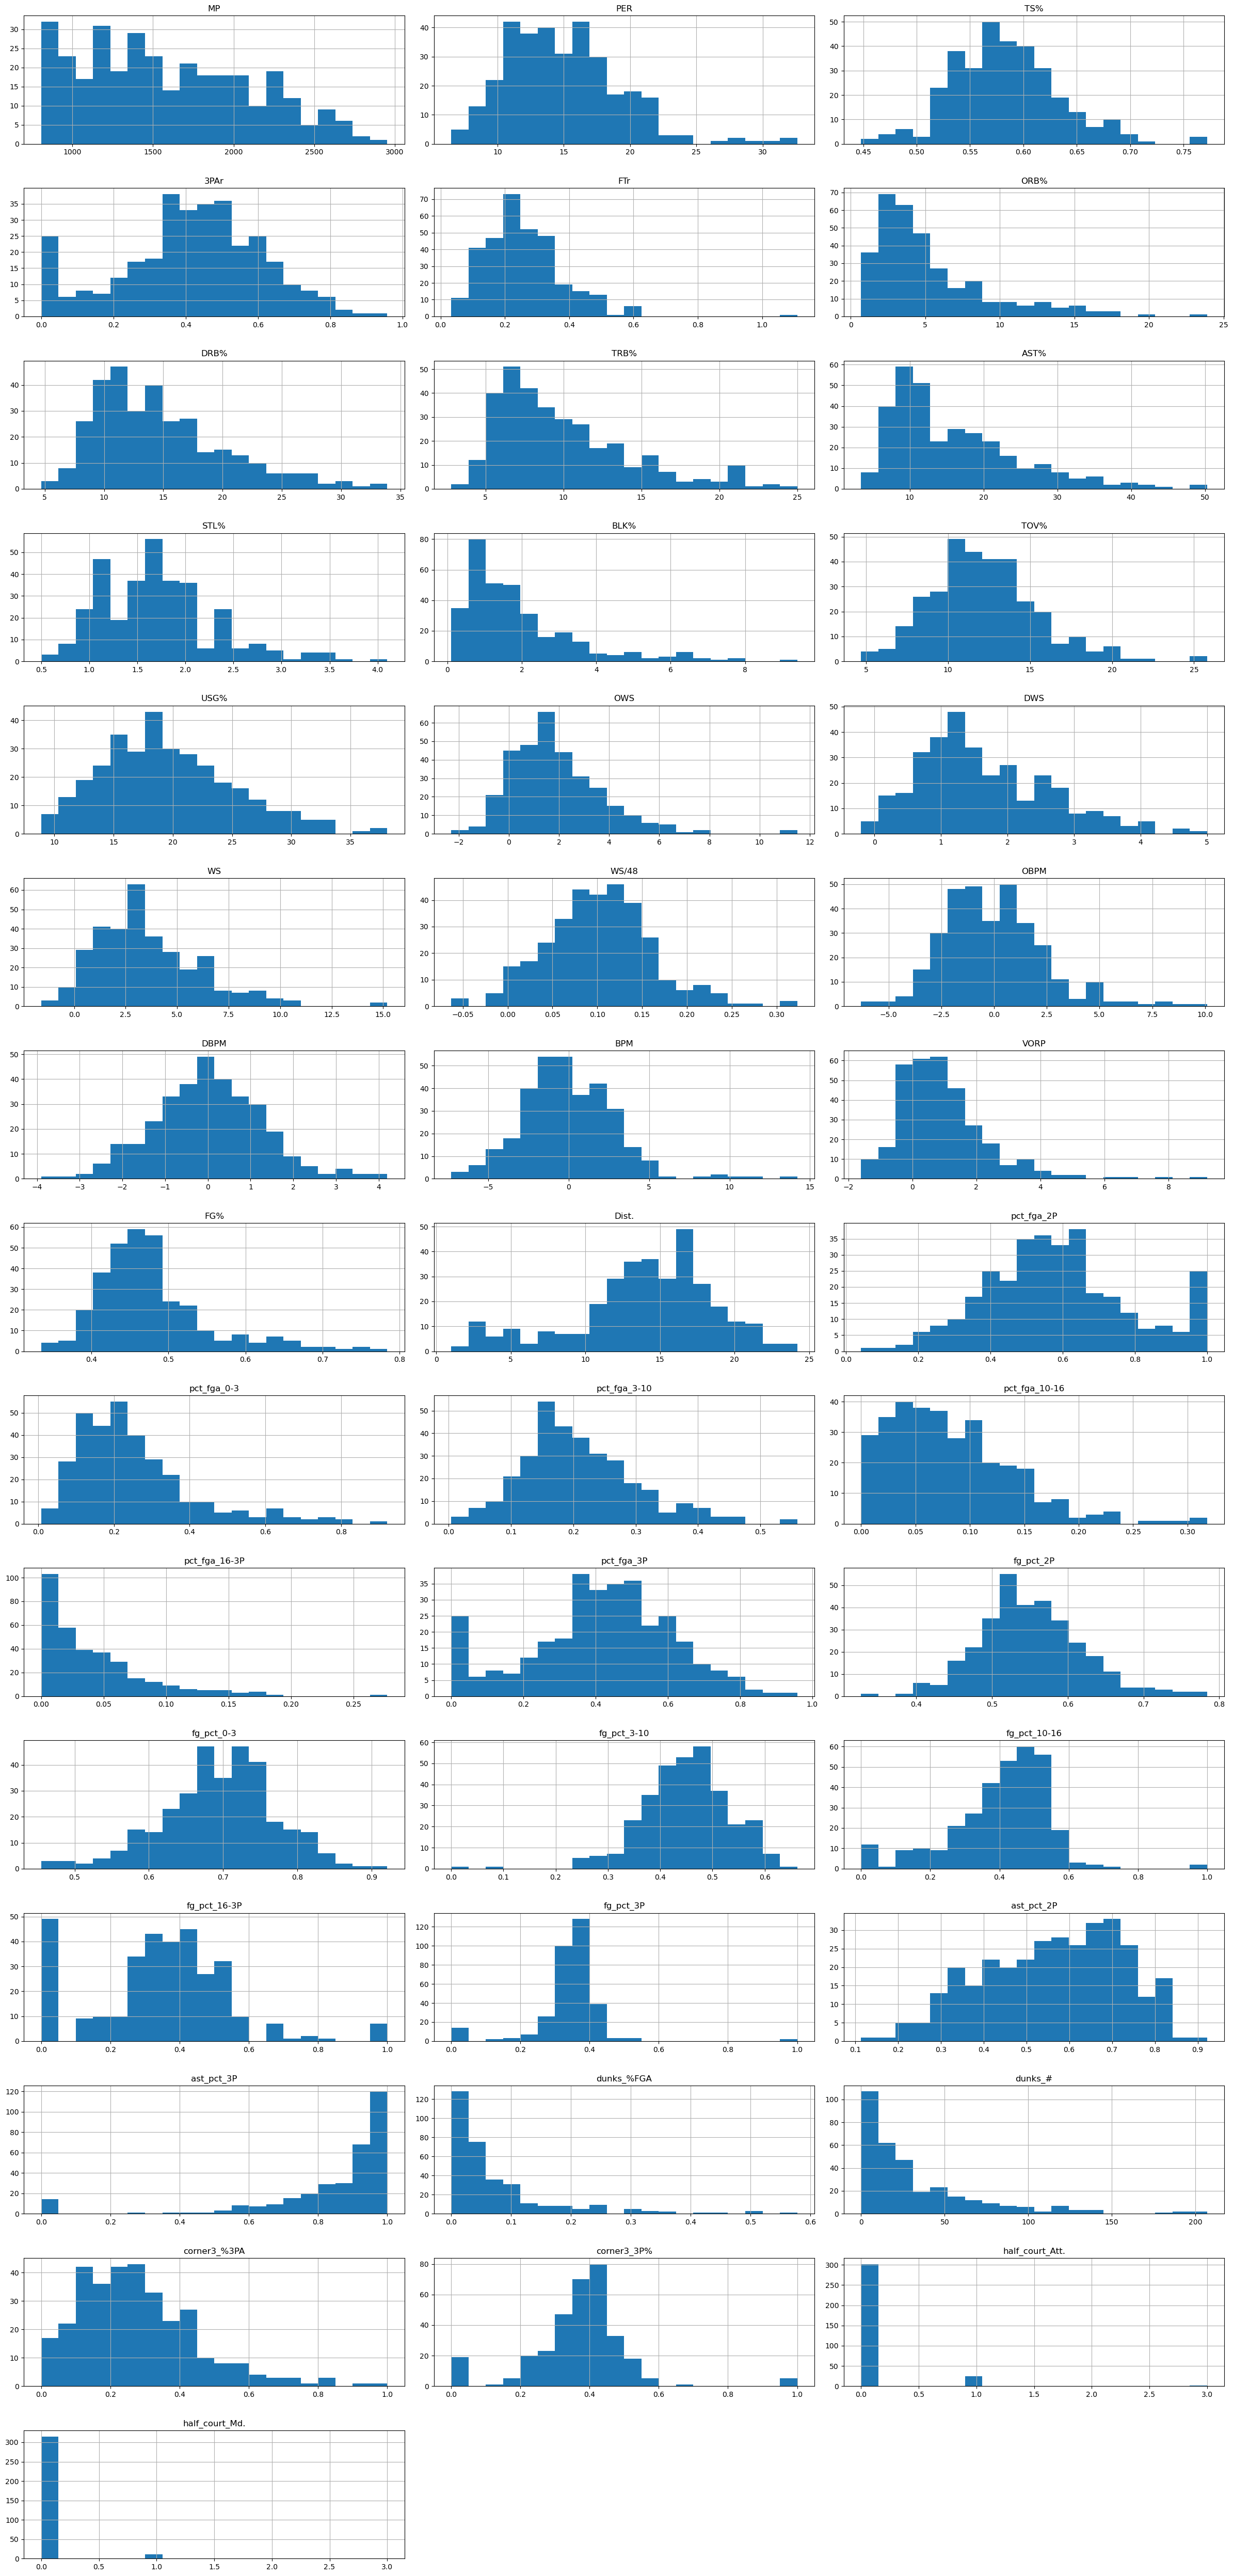

In [14]:
# Grab only numeric columns from df2
num_cols = df2.select_dtypes(include="number").columns

df2[num_cols].hist(bins=20, figsize=(24, 50), layout=(-1, 3))
plt.tight_layout(h_pad=3)
plt.show()

The data shows Skewed histograms with long tails whitch often indicate outliers.

In [15]:
#checking outliers for just numerical data 
from scipy.stats import zscore

z_scores = df2[num_cols].apply(zscore)
outliers = (abs(z_scores) > 3).sum().sort_values(ascending=False)
print("Number of outliers per feature:\n", outliers)


Number of outliers per feature:
 fg_pct_3P          16
ast_pct_3P         14
half_court_Md.     12
BLK%                7
dunks_%FGA          7
fg_pct_16-3P        7
pct_fga_0-3         7
pct_fga_16-3P       6
FG%                 6
pct_fga_10-16       5
BPM                 5
corner3_3P%         5
corner3_%3PA        5
dunks_#             5
ORB%                5
OBPM                5
VORP                5
AST%                4
PER                 4
STL%                4
DBPM                3
TOV%                3
TRB%                3
OWS                 3
TS%                 3
DRB%                3
fg_pct_2P           3
WS/48               2
USG%                2
DWS                 2
fg_pct_10-16        2
fg_pct_3-10         2
fg_pct_0-3          2
WS                  2
pct_fga_3-10        2
FTr                 1
half_court_Att.     1
pct_fga_3P          0
ast_pct_2P          0
3PAr                0
pct_fga_2P          0
Dist.               0
MP                  0
dtype: int64


### Outlier Detection with Z-Scores

To make sure clusters are clean and not distorted by unusual players, I used **z-scores** to find outliers.  

- A **z-score** tells us how far a value is from the average, in standard deviations.  
- Players with a z-score greater than **3 or less than -3** are considered extreme outliers.  
- This is the best approach here because it works across all numeric stats and is easy to apply consistently.  

In [16]:
#Keep only rows where all z-scores are within 3 std dev
#df_no_outliers = df2[(abs(z_scores) < 3).all(axis=1)].reset_index(drop=True)

#print("Before:", len(df2))
#print("After removing outliers:", len(df_no_outliers))


In [17]:
##checking the shape of my data after removing Outliers
print(df2.shape)

(327, 46)


In [18]:
# checking to see tight or Big spreads(good for clustering)
df2.describe()


,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,...,fg_pct_16-3P,fg_pct_3P,ast_pct_2P,ast_pct_3P,dunks_%FGA,dunks_#,corner3_%3PA,corner3_3P%,half_court_Att.,half_court_Md.
count,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,...,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000,327.000000
mean,1591.752294,14.977064,0.583737,0.414257,0.259927,5.299388,14.722018,10.010398,15.966972,1.702752,...,0.342086,0.340355,0.560939,0.843373,0.073511,32.513761,0.276768,0.369076,0.082569,0.042813
std,521.599142,4.317520,0.050396,0.199492,0.123476,3.899449,5.537547,4.318509,8.682675,0.589654,...,0.203346,0.102646,0.160363,0.218775,0.094840,37.583595,0.172228,0.144983,0.307227,0.243949
min,807.000000,6.500000,0.448000,0.000000,0.033000,0.700000,4.700000,2.800000,3.400000,0.500000,...,0.000000,0.000000,0.114000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1160.000000,11.750000,0.548000,0.305000,0.172500,2.600000,10.600000,6.800000,9.450000,1.250000,...,0.250000,0.319500,0.438000,0.802000,0.014000,7.000000,0.151000,0.322500,0.000000,0.000000
50%,1503.000000,14.500000,0.579000,0.431000,0.243000,3.900000,13.600000,8.800000,13.400000,1.600000,...,0.361000,0.355000,0.577000,0.923000,0.041000,20.000000,0.253000,0.382000,0.000000,0.000000
75%,1987.000000,17.300000,0.611500,0.545000,0.326000,6.700000,17.450000,12.400000,20.500000,2.000000,...,0.456500,0.384000,0.690000,0.976000,0.091500,46.500000,0.364500,0.435500,0.000000,0.000000
max,2953.000000,32.600000,0.772000,0.958000,1.109000,23.900000,33.900000,25.000000,50.300000,4.100000,...,1.000000,1.000000,0.922000,1.000000,0.578000,207.000000,1.000000,1.000000,3.000000,3.000000


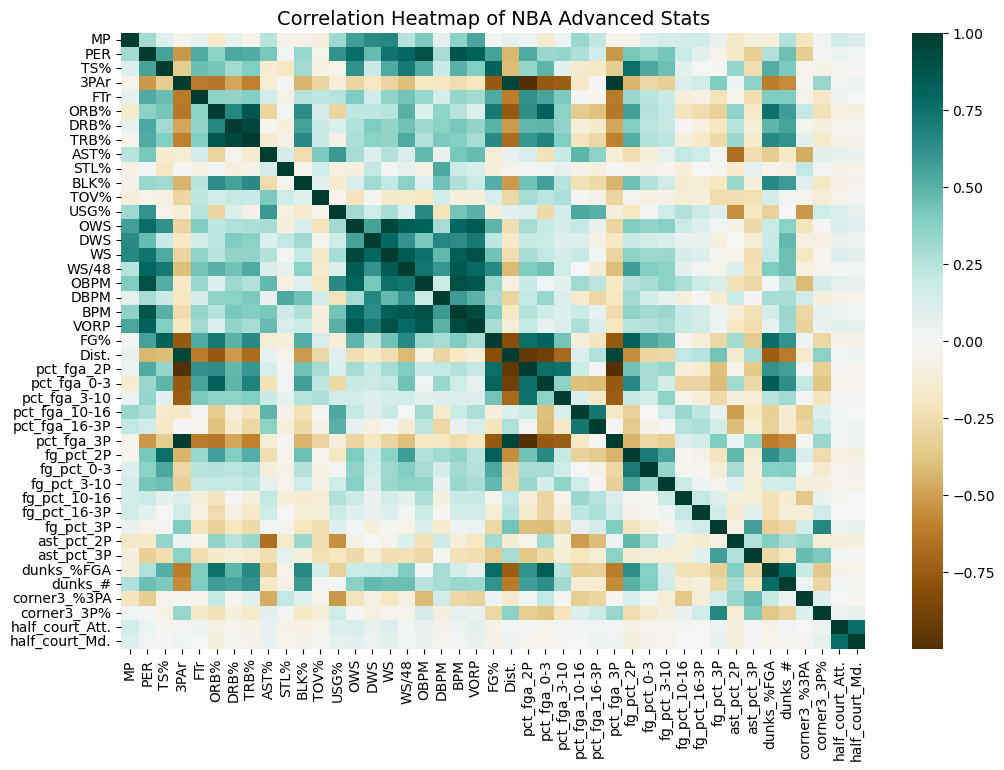

In [19]:
#correlation heatmap to see relationships for numerical stats only
# Select only numeric stats
stats_df = df2.select_dtypes(include=['float64','int64'])


# Correlation heatmap
plt.figure(figsize=(12,8))
c = stats_df.corr()
sns.heatmap(c, cmap="BrBG", annot=False)  # annot=False keeps it cleaner for big matrices
plt.title("Correlation Heatmap of NBA Advanced Stats", fontsize=14)
plt.show()

In [49]:
print(df2.columns.tolist())

['Player', 'Team', 'Pos', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG%', 'Dist.', 'pct_fga_2P', 'pct_fga_0-3', 'pct_fga_3-10', 'pct_fga_10-16', 'pct_fga_16-3P', 'pct_fga_3P', 'fg_pct_2P', 'fg_pct_0-3', 'fg_pct_3-10', 'fg_pct_10-16', 'fg_pct_16-3P', 'fg_pct_3P', 'ast_pct_2P', 'ast_pct_3P', 'dunks_%FGA', 'dunks_#', 'corner3_%3PA', 'corner3_3P%', 'half_court_Att.', 'half_court_Md.']


As you can see the heatmap shows correlation between features represented by the color Green. Correlation among features can negatively influence clustering. PER% and TS% appear to be highly correlated.

## Feature Engineering & Preprocessing

In [21]:
#stats have different scales. 
# If you don’t scale, clustering will give more weight to features with larger numbers
# Select only numeric feature columns for clustering
# Select only numeric columns

from sklearn.preprocessing import RobustScaler


features = [
    # Star playmakers — add these
    'PER', 'TS%', 'USG%', 'AST%', 'VORP', 'WS/48', 'OWS', 'DBPM',
    'BPM',       # ← add this
    'TOV%',      # ← add this (stars turn it over more, role players less)

    # Floor spacers — strengthen these
    '3PAr',
    'fg_pct_3P',
    'corner3_%3PA',
    'corner3_3P%',   # add this back
    'Dist.',

    # Interior bigs — keep but remove one of the redundant pairs
    'ORB%', 'BLK%',
    'pct_fga_0-3',
    'dunks_%FGA'
]



# Subset to just these features
X = df2[features]

# Scale them so they’re on the same range
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (keeps column names for readability)
X_scaled = pd.DataFrame(X_scaled, columns=features) #creating a new object so not to overwrite df_no_outliers/df2
X_scaled.head()     

,PER,TS%,USG%,AST%,VORP,WS/48,OWS,DBPM,BPM,TOV%,3PAr,fg_pct_3P,corner3_%3PA,corner3_3P%,Dist.,ORB%,BLK%,pct_fga_0-3,dunks_%FGA
0,-0.918919,0.755906,-0.649007,-0.380090,-1.000000,-0.736111,0.181818,-1.058824,-0.821918,-0.384615,1.937500,0.992248,0.023419,1.070796,1.794393,-0.585366,-0.6250,-1.162242,-0.503226
1,0.720721,0.645669,0.397351,0.027149,0.133333,0.694444,0.363636,-0.705882,0.547945,-1.128205,-0.154167,0.527132,-0.051522,0.575221,-0.149533,0.512195,-0.3125,0.418879,0.929032
2,-0.666667,-0.393701,0.119205,-0.361991,-0.800000,-1.069444,-0.681818,-0.941176,-0.849315,-0.461538,0.458333,0.372093,0.098361,0.460177,0.504673,-0.024390,0.0625,-0.418879,-0.180645
3,-0.504505,-0.645669,0.132450,-0.253394,-0.200000,-0.430556,-0.909091,0.411765,-0.164384,0.153846,0.304167,0.015504,0.131148,-0.123894,0.112150,-0.146341,0.3125,0.094395,-0.077419
4,-0.522523,-0.724409,0.331126,-0.334842,-1.266667,-1.444444,-0.909091,-1.470588,-1.123288,-0.410256,0.062500,-0.170543,0.037471,-0.654867,0.355140,0.390244,0.6250,-0.454277,0.800000


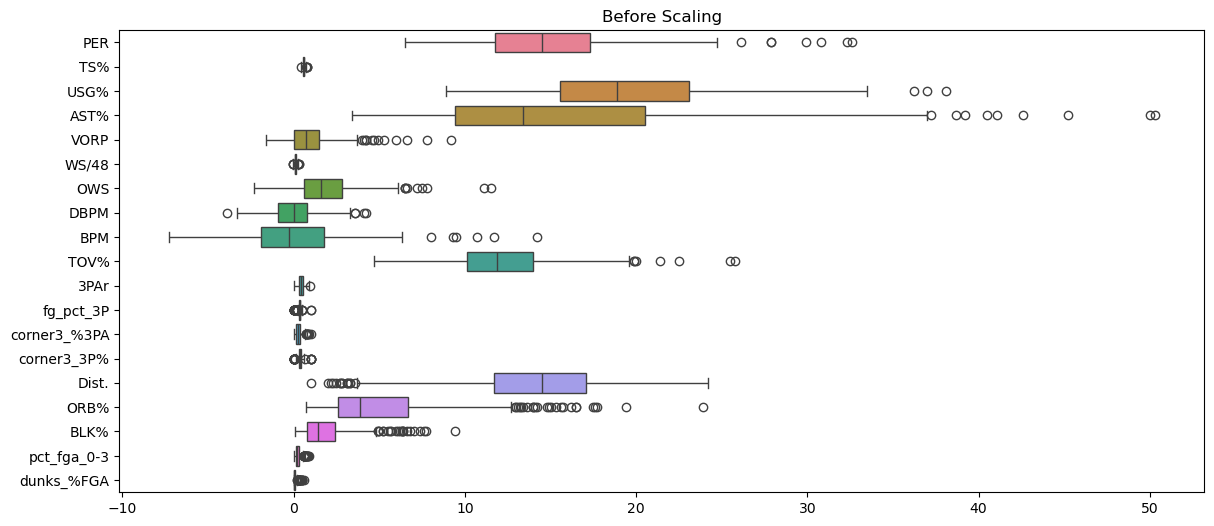

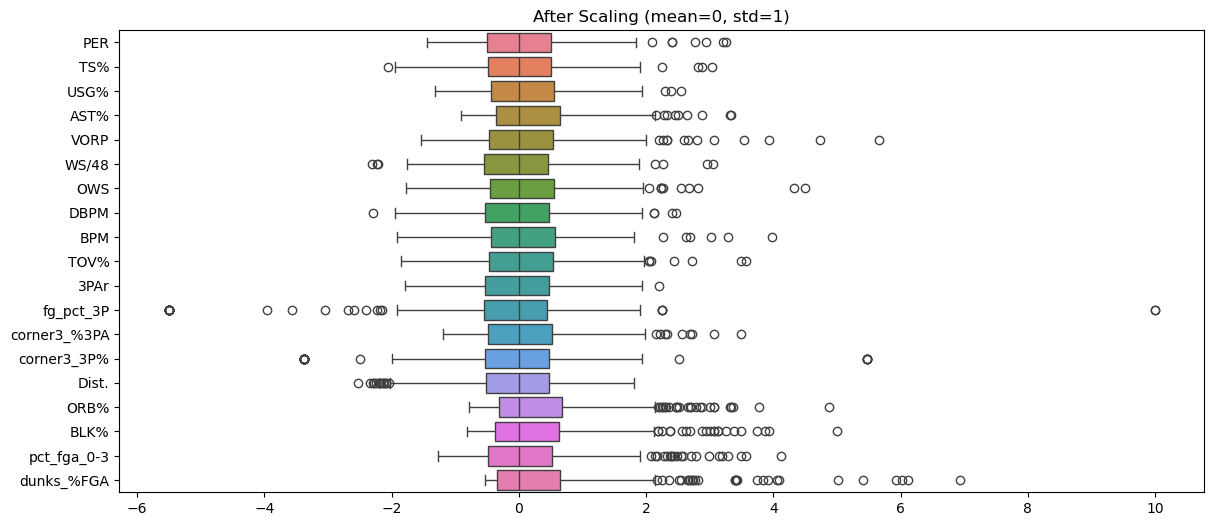

In [22]:
# BEFORE SCALING ---- Features on very different scales
plt.figure(figsize=(14,6))
sns.boxplot(data=X, orient="h")
plt.title("Before Scaling")
plt.show()

# AFTER SCALING ---- reuse X_scaled from earlier
plt.figure(figsize=(14,6))
sns.boxplot(data=X_scaled, orient="h")
plt.title("After Scaling (mean=0, std=1)")
plt.show()

Scaling keeps converts features onto the same scale. This makes sure clustering won’t “think” PER is more important than WS just because it has bigger numbers.

## Dimensionality Reduction (PCA/t-SNE)

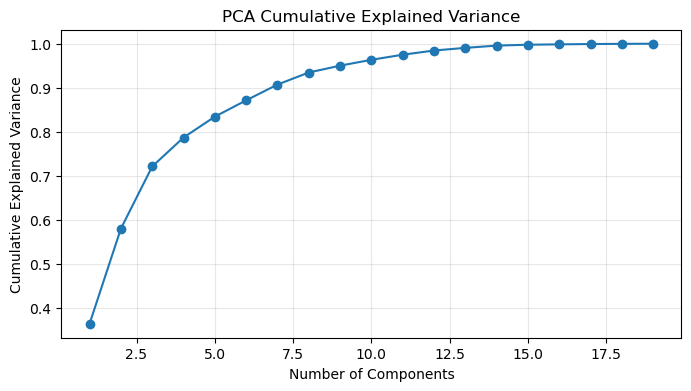

In [23]:
# ---------- PCA: fit + explained variance ----------
pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Scree plot (explained variance ratio)
plt.figure(figsize=(8,4))
evr = pca.explained_variance_ratio_
plt.plot(range(1, len(evr)+1), np.cumsum(evr), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.show()

**PCA** transforms correlated features into a new set of uncorrelated components 
called principal components. Each component is a weighted mix of the original 
features. Since stats like PER and TS% are strongly correlated, PCA rolls them 
into a single component instead of double-counting.

Looking at the scree plot, the curve shows:

- The first 2 components alone capture approximately 58% of the variance.
- By component 5 we reach roughly 80%.
- By component 10 we cross 95%.
- After component 14 the curve flattens and additional components add 
  almost nothing.

14 PCA components were selected to capture approximately 95% of the variance, 
reducing from 18 features to 14 uncorrelated inputs for clustering while 
preserving nearly all of the information.

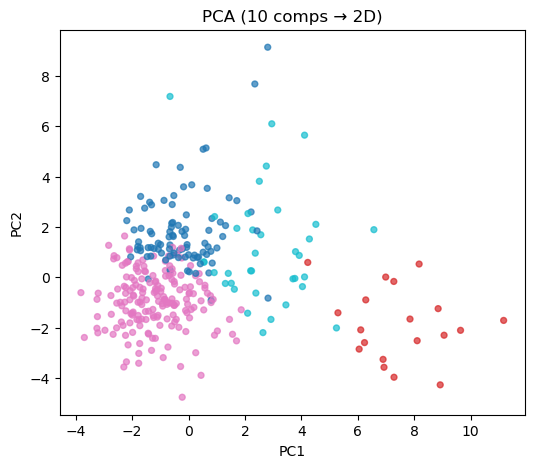

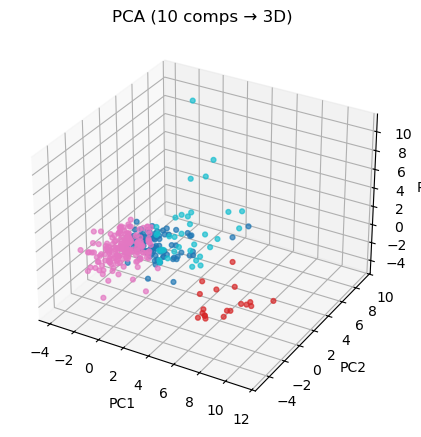

In [24]:
# PCA to 10 comps FROM X_scaled (not from X_pca)
pca = PCA(n_components=14, random_state=42)
X_pca10 = pca.fit_transform(X_scaled)

# KMeans with 3 clusters on that 10-D PCA space
kmeans = KMeans(n_clusters=4, random_state=42, n_init=50)
labels_kmeans = kmeans.fit_predict(X_pca10)

# 2D plot (PC1 vs PC2)
plt.figure(figsize=(6,5))
plt.scatter(X_pca10[:,0], X_pca10[:,1], c=labels_kmeans, cmap="tab10", s=18, alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (10 comps → 2D)')
plt.show()

# 3D plot (PC1 vs PC2 vs PC3)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca10[:,0], X_pca10[:,1], X_pca10[:,2], c=labels_kmeans, cmap="tab10", s=12, alpha=0.7)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('PCA (10 comps → 3D)')
plt.show()

PCA reduces the many stats into a few main patterns. PC1 and PC2 capture the two biggest ways players differ. The scatter plot shows each player in this reduced space — players with similar roles cluster together, and the colors represent the archetypes I found. Four clusters represents four archetypes.

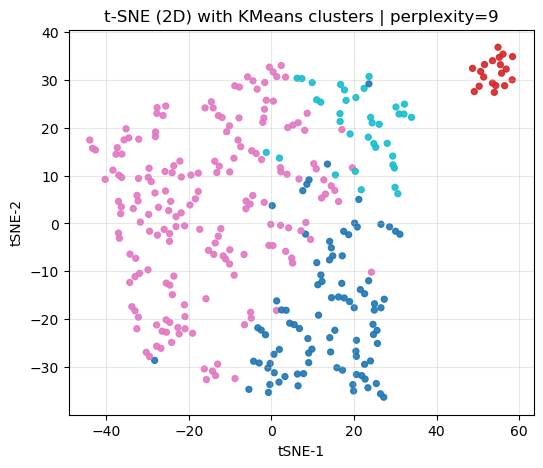

In [25]:
from sklearn.manifold import TSNE

# --- t-SNE setup ---
n = len(X_pca10)   # number of players
perp = int(np.clip(np.sqrt(n)/2, 5, 50))  # rule of thumb for perplexity

tsne = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_pca10)  # project to 2D

# --- Plot t-SNE with cluster labels ---
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=labels_kmeans, cmap="tab10", s=18, alpha=0.9)
plt.title(f't-SNE (2D) with KMeans clusters | perplexity={perp}')
plt.xlabel('tSNE-1'); plt.ylabel('tSNE-2')
plt.grid(alpha=0.3)
plt.show()

## t-SNE Visualization

I also used t-SNE as a visualization tool. Unlike PCA, which shows the biggest 
overall patterns, t-SNE focuses on local similarity — who is close to who.

The t-SNE scatterplot shows four visible groupings that align with the archetypes 
the model found:

- The red cluster (top right) is tight and fully isolated — these are the 
  Interior Enforcers, the most statistically distinct group in the dataset.
- The teal cluster separates cleanly from the pink and blue groups — 
  these are the Rim Runners.
- The pink and blue clusters are larger and sit closer together, reflecting 
  the natural overlap between Floor Spacers and Star Playmakers on the 
  perimeter statistical profile.

The separation of Interior Enforcers into their own isolated island confirms 
that pure paint bigs are the most unique archetype in the NBA. The proximity 
of the perimeter clusters reflects a real basketball truth, the line between 
a star and a role player is not always a hard boundary in the data.

k=2, silhouette=0.431
k=3, silhouette=0.210
k=4, silhouette=0.208
k=5, silhouette=0.159
k=6, silhouette=0.159
k=7, silhouette=0.154
k=8, silhouette=0.143
k=9, silhouette=0.153


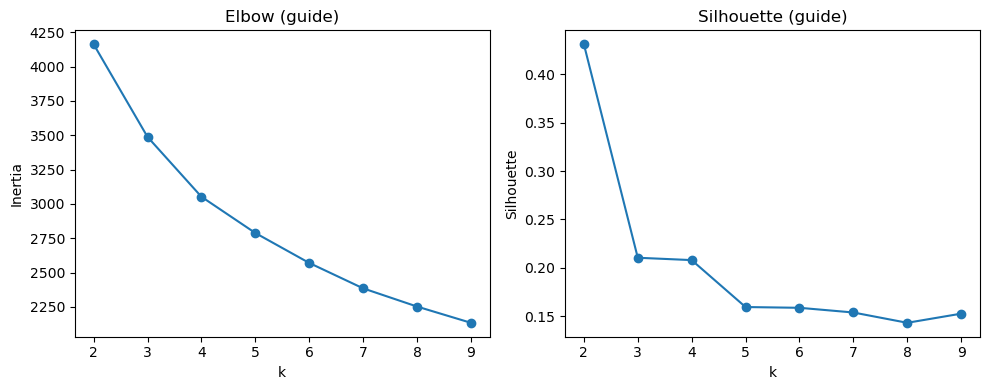


 Best k by silhouette: 2 (score=0.431)


In [26]:
# Range of k values to test
K_range = range(2, 10)
inertias, silhouettes = [], {}

# Loop through each k and compute inertia + silhouette
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=12)
    labels = km.fit_predict(X_pca10)
    inertias.append(km.inertia_)
    silhouettes[k] = silhouette_score(X_pca10, labels)
    print(f"k={k}, silhouette={silhouettes[k]:.3f}")

# Plot elbow (inertia) and silhouette scores
plt.figure(figsize=(10,4))

# Elbow method
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow (guide)")
plt.xlabel("k")
plt.ylabel("Inertia")

# Silhouette method
plt.subplot(1, 2, 2)
plt.plot(list(silhouettes.keys()), list(silhouettes.values()), marker='o')
plt.title("Silhouette (guide)")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

# Pick best k by silhouette score
best_k = max(silhouettes, key=silhouettes.get)
print(f"\n Best k by silhouette: {best_k} (score={silhouettes[best_k]:.3f})")

## Clustering Analysis

### How I Chose the Number of Clusters

I tested different numbers of clusters (k = 2 to 10) and used two guides:

1. **Elbow Method (left plot)**  
   - The line shows how "inertia" (within-cluster error) drops as k increases.  
   - The curve flattens after k=5, meaning adding more clusters doesn’t improve much.  

2. **Silhouette Score (right plot)**  
   - Measures how clearly separated the clusters are (range -1 to 1).  
   - Higher values mean sharper separation.  
   - The best score is at k=2, with k=3 also reasonably strong.  

**Takeaway:**  
- The math says k=2 (and possibly k=3) gives the cleanest split.
- k=3 improves interpretability for basketball roles with only a small silhouette trade-off. It’s a better fit to tell a story. 

In [27]:
# ===============================
# Compare alternative clustering models
# ===============================

from sklearn.cluster import AgglomerativeClustering, DBSCAN

# --- Agglomerative Clustering: range of k values to test ---
K_range = range(2, 10)
silhouettes_hier = {}

for k in K_range:
    hier = AgglomerativeClustering(n_clusters=k)
    labels_hier = hier.fit_predict(X_pca10)
    silhouettes_hier[k] = silhouette_score(X_pca10, labels_hier)
    print(f"k={k}, silhouette={silhouettes_hier[k]:.3f}")

# --- Pick best k by silhouette score ---
best_k_hier = max(silhouettes_hier, key=silhouettes_hier.get)
print(f"\nBest k for Agglomerative by silhouette: {best_k_hier} "
      f"(score={silhouettes_hier[best_k_hier]:.3f})")


# --- DBSCAN ---
db = DBSCAN(eps=2.0, min_samples=11)  # match it tp the same # of components for PCA
labels_db = db.fit_predict(X_pca10)

print("DBSCAN silhouette:", silhouette_score(X_pca10, labels_db))

k=2, silhouette=0.507
k=3, silhouette=0.342
k=4, silhouette=0.307
k=5, silhouette=0.133
k=6, silhouette=0.137
k=7, silhouette=0.124
k=8, silhouette=0.129
k=9, silhouette=0.121

Best k for Agglomerative by silhouette: 2 (score=0.507)
DBSCAN silhouette: 0.19003288446119043


## Comparing Alternative Clustering Models

After running KMeans, I also tested two additional unsupervised clustering models
using the PCA-transformed player statistics.

### Agglomerative Clustering

Agglomerative clustering builds groups step by step. It begins by treating each
player as an individual cluster, then progressively merges similar players together.

- k=2 produced the strongest separation with a silhouette score of 0.507.
- k=3 scored 0.342 and k=4 scored 0.307.
- Scores drop sharply after k=4, suggesting the data does not support
  more than four meaningful groupings.
- The best k by silhouette is 2, but k=4 was chosen to produce four
  interpretable basketball archetypes with only a modest silhouette trade-off.

### DBSCAN

DBSCAN does not require a preset number of clusters. Instead, it identifies dense
groups of similar players and labels isolated observations as noise.

- I set min_samples=11 to align with the 14 PCA components.
- DBSCAN produced a silhouette score of 0.190.
- While positive, the score indicates weak cluster structure. DBSCAN struggled
  because NBA player data does not form the tight density groups that DBSCAN
  is designed to detect.

### Takeaway

- Agglomerative Clustering (k=2) produced the strongest mathematical separation
  with a silhouette score of 0.507.
- k=4 was selected over k=2 because four archetypes tell a richer basketball
  story with only a 0.200 silhouette trade-off.
- DBSCAN scored 0.190, the weakest of the three models, and was not used
  for the final analysis.

### Align PCA and scaled features

In [28]:
# Ensure X_scaled is a DataFrame with the right index/columns
X_scaled_df = (
    X_scaled if isinstance(X_scaled, pd.DataFrame)
    else pd.DataFrame(X_scaled, index=df2.index, columns=features)
)

# Ensure X_pca10 is a DataFrame aligned to the SAME rows as X_scaled_df
X_pca10_df = (
    X_pca10 if isinstance(X_pca10, pd.DataFrame)
    else pd.DataFrame(X_pca10, index=X_scaled_df.index, columns=[f"PC{i+1}" for i in range(np.asarray(X_pca10).shape[1])])
)

print("Shapes -> X_scaled_df:", X_scaled_df.shape, " | X_pca10_df:", X_pca10_df.shape)


Shapes -> X_scaled_df: (327, 19)  | X_pca10_df: (327, 14)


**Before any clustering we have to make sure the data tables are properly lined up before clustering**:  

- **X_scaled_df** → the scaled version of our stats, with the same player index and column names.  
- **X_pca10_df** → the PCA projection of those stats, but also forced to keep the same row order and player index as X_scaled_df.  

This way, every row in PCA space still matches the correct player in the original dataset.  
If the shapes or indices don’t line up, cluster labels could get mis-assigned to the wrong players.  

In [37]:
#k=4
#kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
#labels_kmeans = kmeans.fit_predict(X_pca10_df)

#uniq, cnts = np.unique(labels_kmeans, return_counts=True)
#print("Cluster sizes:", dict(zip(uniq, cnts)))

In [39]:
# Final Agglomerative Clustering (k=3 or best_k_hier if computed above)
k = 4  
hier = AgglomerativeClustering(n_clusters=k)
labels_hier = hier.fit_predict(X_pca10_df)

#sanity check: cluster sizes
uniq, cnts = np.unique(labels_hier, return_counts=True)
print("Cluster sizes:", dict(zip(uniq, cnts)))

Cluster sizes: {np.int64(0): np.int64(251), np.int64(1): np.int64(28), np.int64(2): np.int64(30), np.int64(3): np.int64(18)}


## Final Agglomerative Clustering

For the final analysis, I used Agglomerative Clustering with k=4 to create four player archetypes.

Agglomerative Clustering outperformed KMeans at every value of k on the updated feature set. At k=4, Agglomerative scored 0.307 vs KMeans at 0.208, making it the stronger choice for this dataset.

Agglomerative Clustering starts by treating every player as their own cluster. It then gradually merges the most similar players until the requested number of clusters is reached. The model was run on the PCA-transformed player statistics and each player was assigned to one of four archetypes.

### Cluster Size Check

The final cluster sizes were:

- Cluster 0: 251 players — Floor Spacers
- Cluster 1: 28 players — Star Playmakers
- Cluster 2: 30 players — Rim Runners
- Cluster 3: 18 players — Interior Enforcers

All players were assigned to a cluster and no clusters were empty. The uneven sizes reflect real NBA roster construction — perimeter role players are the most common profile in the league, while pure paint bigs and elite stars are rare by definition.


In [40]:
#  cluster profiles in original feature space
cluster_ids = np.sort(np.unique(labels_hier))
feat_names  = list(X_scaled_df.columns)

Z_means = np.vstack([
    X_scaled_df.iloc[labels_hier == cid].mean(axis=0).values
    for cid in cluster_ids
])
summ = pd.DataFrame(Z_means, index=cluster_ids, columns=feat_names)

This step calculates the **average stat profile** for each cluster.  

- First, it finds the different clusters that Agglomerative  created.  
- Then, for each cluster, it looks at all the players inside and computes their **average z-scores** (how far above or below league average they are) for every stat.  
- Finally, it stores these averages in a table called (`summ`).  

This table makes it easy to see what makes each cluster unique — for example, one group might average high rebounds and blocks, while another averages high shooting efficiency.  

In [41]:
# read the clusters
print("Cluster means (z-scores) ALL features:")
print(summ.round(2))   

for i, cid in enumerate(cluster_ids):
    row = Z_means[i]
    hi = np.argsort(-row)[:4]
    lo = np.argsort(row)[:4]
    print(f"\nCluster {cid} (n={(labels_hier==cid).sum()})")
    print("  Strongest:", [f"{feat_names[j]}({row[j]:.2f})" for j in hi])
    print("  Weakest:  ", [f"{feat_names[j]}({row[j]:.2f})" for j in lo])

Cluster means (z-scores) ALL features:
    PER   TS%  USG%  AST%  VORP  WS/48   OWS  DBPM   BPM  TOV%  3PAr  \
0 -0.19 -0.14  0.03  0.17 -0.11  -0.30 -0.12 -0.12 -0.15  0.00  0.21   
1  1.48  0.48  1.39  1.39  2.17   1.06  1.65  0.35  1.53  0.11 -0.35   
2  0.73  0.67 -0.19 -0.06  0.39   0.73  0.51  0.48  0.46  0.28 -1.14   
3  0.72  1.41 -0.53 -0.26  0.37   1.04  0.81  0.56  0.44  0.64 -1.75   

   fg_pct_3P  corner3_%3PA  corner3_3P%  Dist.  ORB%  BLK%  pct_fga_0-3  \
0       0.01          0.16         0.05   0.19  0.02  0.05        -0.13   
1       0.13         -0.65         0.05  -0.09  0.13  0.34        -0.09   
2       0.34          0.74         0.26  -1.41  2.00  1.55         1.65   
3      -5.02         -0.48        -3.26  -2.07  2.33  1.71         2.39   

   dunks_%FGA  
0        0.04  
1       -0.03  
2        2.22  
3        3.43  

Cluster 0 (n=251)
  Strongest: ['3PAr(0.21)', 'Dist.(0.19)', 'AST%(0.17)', 'corner3_%3PA(0.16)']
  Weakest:   ['WS/48(-0.30)', 'PER(-0.19)', 'B


## Justifying archetype names for this project.
This step is about reading what each cluster actually looks like. It prints the average stat values (z-scores) for every feature across players in each cluster and highlights the top 4 strongest and weakest stats per cluster.

This is how we decide what to call each archetype:
- If a cluster is strong in rebounds, blocks, and paint finishing but weak in three point shooting, we name it **Interior Enforcers**.
- If a cluster is strong in playmaking and impact stats like VORP, BPM, and OWS, we name it **Star Playmakers**.
- If a cluster is strong in dunks, offensive rebounding, and rim finishing but weaker in perimeter creation, we name it **Rim Runners**.
- If a cluster shows above average three point attempt rate and shot distance but below average impact stats, we name it **Floor Spacers**.

This step gives the evidence for assigning human-readable archetype names before any labels are applied.

In [42]:
name_map = {
    0: "Floor Spacers",
    1: "Star Playmakers",
    2: "Rim Runners",
    3: "Interior Enforcers"
}

**This creates a dictionary called name_map that translates cluster numbers into basketball archetypes.**

Cluster 0 → **Floor Spacers**

Cluster 1 → **Star Playmakers**

Cluster 2 → **Rim Runners**

Cluster 3 → **Interior Enforcers**

**Instead of showing clusters as just numbers, this makes the results readable for humans. It connects the math to basketball roles.**

In [45]:
#  assignments table
assignments = df2[['Player','Pos','Team']].copy()
assignments['cluster']   = labels_hier
assignments['archetype'] = assignments['cluster'].map(name_map)

# sanity peek
for c in cluster_ids:
    group = assignments[assignments['cluster'] == c]
    print(f"\n=== Cluster {c}: {name_map[c]} (n={len(group)}) ===")
    print(group.sample(min(5, len(group)), random_state=42).to_string(index=False))


=== Cluster 0: Floor Spacers (n=251) ===
         Player Pos Team  cluster     archetype
Kyle Filipowski   C  UTA        0 Floor Spacers
     Al Horford   C  GSW        0 Floor Spacers
  Matas Buzelis  PF  CHI        0 Floor Spacers
Dennis Schröder  PG  2TM        0 Floor Spacers
Jaylin Williams  PF  OKC        0 Floor Spacers

=== Cluster 1: Star Playmakers (n=28) ===
        Player Pos Team  cluster       archetype
 Jalen Johnson  SF  ATL        1 Star Playmakers
 Stephen Curry  PG  GSW        1 Star Playmakers
 Jalen Brunson  PG  NYK        1 Star Playmakers
    Luka Garza   C  BOS        1 Star Playmakers
Alperen Şengün   C  HOU        1 Star Playmakers

=== Cluster 2: Rim Runners (n=30) ===
               Player Pos Team  cluster   archetype
     Precious Achiuwa   C  SAC        2 Rim Runners
Giannis Antetokounmpo  PF  MIL        2 Rim Runners
    Marvin Bagley III  PF  2TM        2 Rim Runners
    Jonas Valančiūnas   C  DEN        2 Rim Runners
      Dominick Barlow  PF  PHI    

In [46]:
#sanity check 
all_nba = ['Gilgeous-Alexander', 'Jokić', 'Wembanyama', 'Dončić',
           'Cunningham', 'Brown', 'Durant', 'Mitchell',
           'Brunson', 'Leonard', 'Maxey', 'Murray', 'Holmgren',
           'Duren', 'Johnson']

hits = assignments[
    assignments['Player'].apply(
        lambda x: any(name in x for name in all_nba)
    )
][['Player', 'Pos', 'Team', 'archetype']]
print(hits.to_string())

                      Player Pos Team           archetype
6              Ajay Mitchell  SG  OKC       Floor Spacers
36               Bruce Brown  SG  DEN       Floor Spacers
41           Cade Cunningham  PG  DET     Star Playmakers
46           Cameron Johnson  SF  DEN       Floor Spacers
51             Chet Holmgren  PF  OKC         Rim Runners
57      Collin Murray-Boyles  PF  TOR         Rim Runners
67           Davion Mitchell  PG  MIA       Floor Spacers
86          Donovan Mitchell  SG  CLE     Star Playmakers
127            Jalen Brunson  PG  NYK     Star Playmakers
128              Jalen Duren   C  DET  Interior Enforcers
130            Jalen Johnson  SF  ATL     Star Playmakers
136             Jamal Murray  PG  DEN     Star Playmakers
149             Jaylen Brown  SF  BOS     Star Playmakers
186            Kawhi Leonard  SF  LAC     Star Playmakers
188           Keldon Johnson  SF  SAS       Floor Spacers
193             Kevin Durant  SF  HOU     Star Playmakers
199           

The model correctly identifies 11 of 15 All-NBA players as Star Playmakers using only unsupervised statistical clustering with no labels. The two exceptions — Wembanyama and Holmgren — reveal something interesting: both players' defensive and interior profiles statistically resemble elite athletic bigs more than perimeter creators, which reflects a genuine tension in how modern versatile bigs get categorized.

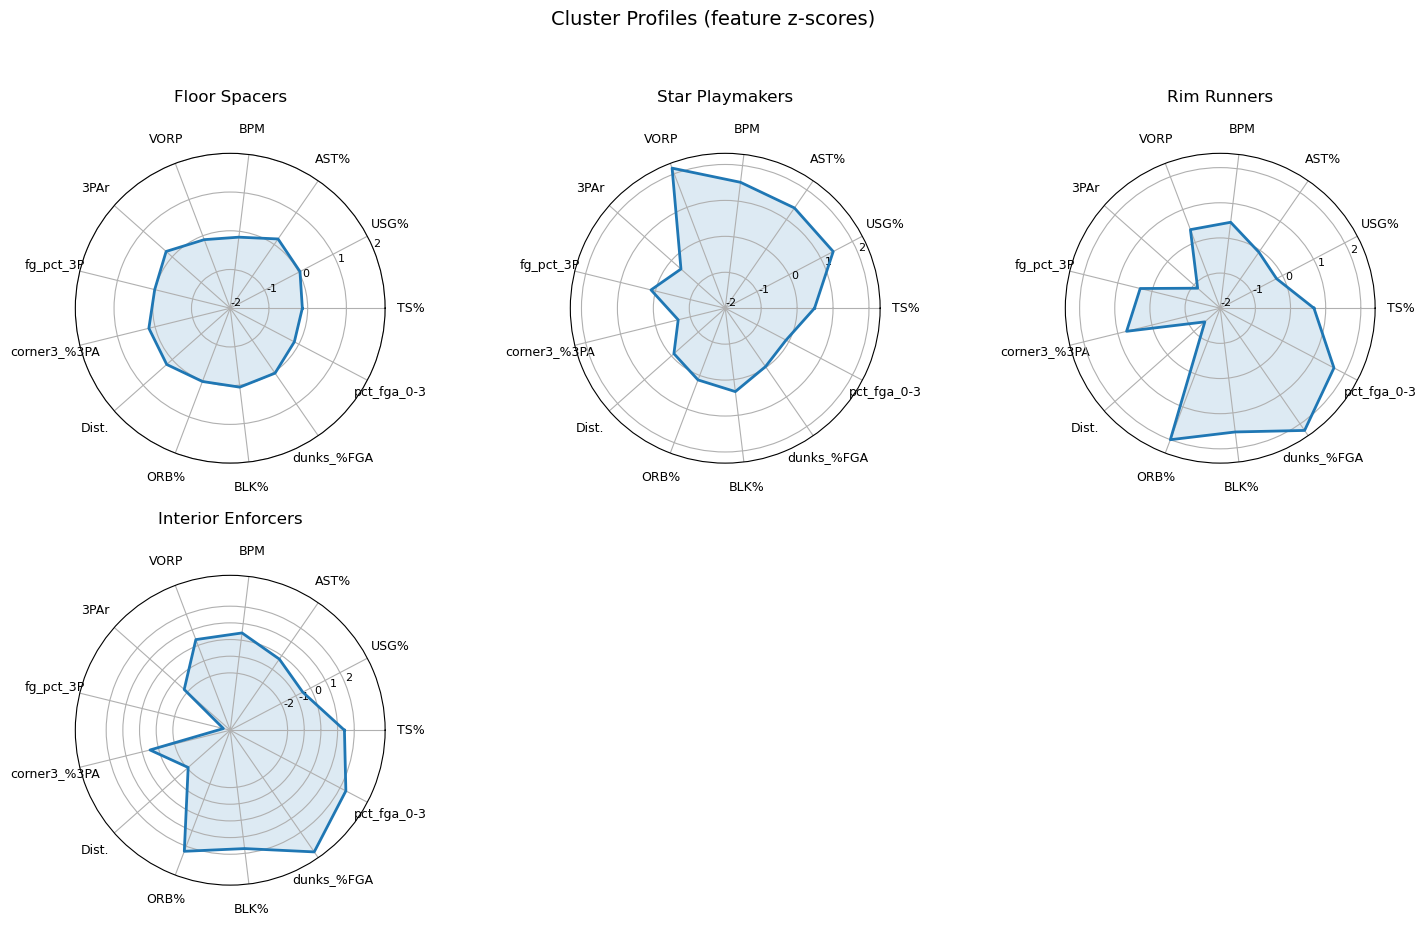

In [48]:
# === Radar charts per cluster (z-score feature profiles) ===
import numpy as np
import matplotlib.pyplot as plt

# 1) Choose which features to show on the radar (order matters)
preferred = [
    'TS%', 'USG%', 'AST%', 'BPM', 'VORP',
    '3PAr', 'fg_pct_3P', 'corner3_%3PA', 'Dist.',
    'ORB%', 'BLK%', 'dunks_%FGA', 'pct_fga_0-3'
]
# Keep only features that exist in X_scaled_df
feat_names = list(X_scaled_df.columns)
radar_features = [f for f in preferred if f in feat_names]
if len(radar_features) == 0:
    raise ValueError("None of the preferred radar features are in X_scaled_df columns.")

# 2) Compute mean z-scores per cluster for those features
cluster_ids = np.sort(np.unique(labels_hier))
Z_means_full = np.vstack([
    X_scaled_df.iloc[labels_hier == cid].mean(axis=0).values
    for cid in cluster_ids
])
# index mapping from full feature list to radar_features
idx_map = [feat_names.index(f) for f in radar_features]
Zm = Z_means_full[:, idx_map]  # shape: (K x F for radar)

# 3) Small helper to draw a radar
def radar_chart(ax, values, labels, title):
    F = len(labels)
    angles = np.linspace(0, 2*np.pi, F, endpoint=False)
    vals = np.r_[values, values[0]]   # close loop
    angs = np.r_[angles, angles[0]]

    ax.plot(angs, vals, linewidth=2)
    ax.fill(angs, vals, alpha=0.15)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.tick_params(axis='x', pad=8)
    ax.set_yticks([-2,-1,0,1,2])
    ax.set_yticklabels(['-2','-1','0','1','2'], fontsize=8)
    ax.set_title(title, fontsize=12, y=1.14)

# 4) Plot one radar per cluster
cols = min(3, len(cluster_ids))
rows = int(np.ceil(len(cluster_ids)/cols))
fig = plt.figure(figsize=(5*cols, 4.7*rows))

for i, cid in enumerate(cluster_ids):
    ax = plt.subplot(rows, cols, i+1, projection='polar')
    title = name_map.get(int(cid), f"Cluster {cid}")  # use your archetype names if provided
    radar_chart(ax, Zm[i], radar_features, title)

plt.suptitle("Cluster Profiles (feature z-scores)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


## Conclusion

NBA players were grouped into four archetypes using unsupervised learning (Agglomerative Clustering with k=4).

- **Floor Spacers (n=251)** — perimeter-oriented players whose shot profile and distance separate them from interior players. The largest group in the league.
- **Star Playmakers (n=28)** — high-impact players who drive team offense through scoring, playmaking, and overall efficiency. All five 2026 First Team All-NBA players landed here.
- **Rim Runners (n=30)** — athletic bigs who dominate at the rim through dunking, offensive rebounding, and paint finishing. Giannis Antetokounmpo is the defining example of this archetype.
- **Interior Enforcers (n=18)** — pure paint bigs with near-zero perimeter activity. The most specialized archetype in the dataset, defined by extreme inside finishing and no three point shooting.

The model placed Giannis in Rim Runners rather than Star Playmakers. This reflects a real tension in how we categorize modern big men. Giannis dominates through athleticism and interior finishing rather than perimeter creation or shooting efficiency, which statistically separates him from guards and wings who drive offense through shooting and playmaking.

By standardizing stats, reducing redundancy with PCA, and letting the data decide natural groupings, this analysis reveals how advanced stats can separate player roles and value beyond the traditional box score.

## Limitations & Next Steps

**Limitations**
- Roles are based on one season. Injuries, coaching changes, or team context can shift how a player's numbers look.
- The 800 minute minimum and feature selection choices reflect judgment calls, not hard rules.
- Agglomerative Clustering produces hard boundaries, but real basketball roles overlap. Giannis and Wembanyama are examples where statistical profile and reputation diverge.

**Next Steps**
- Test stability by running this across multiple seasons to see if player roles shift over time.
- Try more flexible models like Gaussian Mixtures or HDBSCAN that handle overlapping clusters.
- Add richer data including lineup impact, tracking stats, and contract value to sharpen archetypes.
- Build a player lookup dashboard so users can instantly see any player's archetype and their closest statistical comparisons.